# Sound Classification


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Install dependencies (run once per environment). Comment this cell out if everything is already installed.
%pip install -q pandas numpy matplotlib seaborn librosa soundfile scikit-learn torch torchaudio torchvision tqdm kaggle ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.4 MB/s eta 0:00:00


In [4]:
import os
import random
import zipfile
import subprocess
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

plt.style.use("seaborn-v0_8")
sns.set_theme(context="notebook")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

from pathlib import Path

PROJECT_ROOT = Path("/content")  # or Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"  # only used for artifacts/checkpoints
DATA_DIR.mkdir(exist_ok=True)

RAW_DATA_ROOT = Path("/content/drive/MyDrive/ESC-50-master")
META_PATH = RAW_DATA_ROOT / "meta" / "esc50.csv"
AUDIO_DIR = RAW_DATA_ROOT / "audio"

SAMPLE_RATE = 22_050
TARGET_DURATION = 5.0  # seconds
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
MAX_SAMPLES = int(SAMPLE_RATE * TARGET_DURATION)

BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0  # Windows-friendly


Using device: cuda


## Data Acquisition


In [5]:
ESC50_DATASET_SLUG = "mmoreaux/environmental-sound-classification-50"


def find_esc50_root(base_dir: Path) -> Path:
    """Return the ESC-50 root folder that contains meta/esc50.csv."""
    meta_match = list(base_dir.glob("**/meta/esc50.csv"))
    if meta_match:
        return meta_match[0].parents[1]
    candidate = base_dir / "ESC-50-master"
    if candidate.exists():
        return candidate
    raise FileNotFoundError("ESC-50 folder not found. Run download_esc50().")


In [7]:
META_PATH = RAW_DATA_ROOT / "meta" / "esc50.csv"
AUDIO_DIR = RAW_DATA_ROOT / "audio"

if not META_PATH.exists():
    raise FileNotFoundError(f"Metadata CSV not found at {META_PATH}")
if not AUDIO_DIR.exists():
    raise FileNotFoundError(f"Audio folder not found at {AUDIO_DIR}")

metadata = pd.read_csv(META_PATH)
print(f"Total clips in ESC-50: {len(metadata):,}")
metadata.head()


Total clips in ESC-50: 2,000


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [8]:
SELECTED_CLASSES = [
    "helicopter",
    "chainsaw",
    "siren",
    "car_horn",
    "engine",
    "train",
    "church_bells",
    "airplane",
    "fireworks",
    "hand_saw"
]

if not (2 <= len(SELECTED_CLASSES) <= 10):
    raise ValueError("Please keep between 2 and 8 labels to satisfy the project scope.")

subset_df = metadata[metadata["category"].isin(SELECTED_CLASSES)].copy()
if subset_df.empty:
    raise ValueError("No rows match SELECTED_CLASSES. Double-check spelling against esc50.csv")

class_to_idx = {cls: idx for idx, cls in enumerate(SELECTED_CLASSES)}
idx_to_class = {v: k for k, v in class_to_idx.items()}
subset_df["target_idx"] = subset_df["category"].map(class_to_idx)

print(f"Clips kept: {len(subset_df)} across {len(SELECTED_CLASSES)} classes")
class_counts = subset_df["category"].value_counts().loc[SELECTED_CLASSES]
class_counts


Clips kept: 400 across 10 classes


,count
category,
helicopter,40
chainsaw,40
siren,40
car_horn,40
engine,40
train,40
church_bells,40
airplane,40
fireworks,40


/tmp/ipython-input-3720035113.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


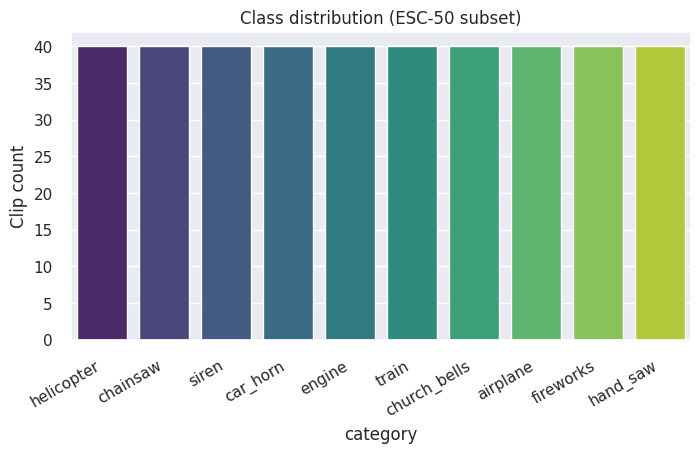

In [9]:
plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Clip count")
plt.title("Class distribution (ESC-50 subset)")
plt.show()


In [10]:
def pad_or_trim(signal: np.ndarray, max_samples: int = MAX_SAMPLES) -> np.ndarray:
    if len(signal) > max_samples:
        return signal[:max_samples]
    if len(signal) < max_samples:
        pad_width = max_samples - len(signal)
        signal = np.pad(signal, (0, pad_width), mode="constant")
    return signal


def waveform_to_mel(signal: np.ndarray, sr: int = SAMPLE_RATE) -> np.ndarray:
    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmax=sr // 2,
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db


def normalize_mel(mel_db: np.ndarray) -> np.ndarray:
    mean = mel_db.mean()
    std = mel_db.std()
    return (mel_db - mean) / (std + 1e-6)


def random_time_shift(signal: np.ndarray, max_shift: int = 2_000) -> np.ndarray:
    if max_shift <= 0:
        return signal
    shift = np.random.randint(-max_shift, max_shift)
    return np.roll(signal, shift)



In [11]:
class Esc50MelDataset(Dataset):
    def __init__(self, df: pd.DataFrame, audio_dir: Path, augment: bool = False):
        self.df = df.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.augment = augment

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.df.iloc[idx]
        file_path = self.audio_dir / row["filename"]
        signal, _ = librosa.load(file_path, sr=SAMPLE_RATE)

        if self.augment:
            signal = random_time_shift(signal)

        signal = pad_or_trim(signal)
        mel = waveform_to_mel(signal)
        mel = normalize_mel(mel)

        mel_tensor = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(row["target_idx"], dtype=torch.long)

        return {
            "input": mel_tensor,
            "label": label,
            "category": row["category"],
            "filename": row["filename"],
        }



In [12]:
train_df, temp_df = train_test_split(
    subset_df,
    test_size=0.3,
    stratify=subset_df["category"],
    random_state=RANDOM_SEED,
)
val_df, _ = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["category"],
    random_state=RANDOM_SEED,
)

print(
    f"Train: {len(train_df)}, Val: {len(val_df)} (test loaded from Drive folder below)"
)

train_dataset = Esc50MelDataset(train_df, AUDIO_DIR, augment=True)
val_dataset = Esc50MelDataset(val_df, AUDIO_DIR, augment=False)

common_loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": device.type == "cuda",
}

train_loader = DataLoader(train_dataset, shuffle=True, **common_loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **common_loader_kwargs)



Train: 280, Val: 60 (test loaded from Drive folder below)


In [15]:
# Build test set from the shared Drive folder (class subfolders with wav files)
TEST_AUDIO_ROOT = Path("/content/drive/MyDrive/ESC-50-master/data test")
# If you added the folder into MyDrive instead of Shared drives, change to:
# TEST_AUDIO_ROOT = Path("/content/drive/MyDrive/data test")


def build_test_df_from_folder(root: Path, selected_classes: List[str]) -> pd.DataFrame:
    rows: List[Dict[str, str]] = []
    root = Path(root)
    for cls in selected_classes:
        cls_dir = root / cls
        if not cls_dir.exists():
            print(f"Warning: missing folder for class '{cls}': {cls_dir}")
            continue
        for audio_path in cls_dir.glob("*.wav"):
            rows.append({
                "filename": f"{cls}/{audio_path.name}",
                "category": cls,
            })
    if not rows:
        raise ValueError(f"No audio files found under {root}. Check the mount/path.")
    df = pd.DataFrame(rows)
    df["target_idx"] = df["category"].map(class_to_idx)
    return df


external_test_df = build_test_df_from_folder(TEST_AUDIO_ROOT, SELECTED_CLASSES)
print(f"External test clips found: {len(external_test_df)}")

# Override test split to use the external clips
test_df = external_test_df

test_dataset = Esc50MelDataset(test_df, TEST_AUDIO_ROOT, augment=False)
test_loader = DataLoader(test_dataset, shuffle=False, **common_loader_kwargs)


External test clips found: 87


Batch mel shape: torch.Size([32, 1, 128, 216])
Batch labels shape: torch.Size([32])


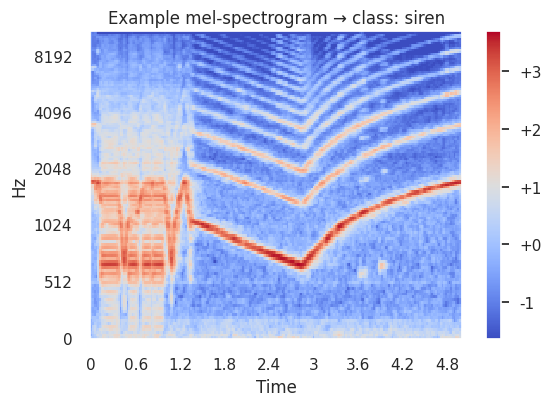

In [16]:
sample_batch = next(iter(train_loader))
inputs = sample_batch["input"]
labels = sample_batch["label"]
print(f"Batch mel shape: {inputs.shape}")
print(f"Batch labels shape: {labels.shape}")

idx = 0
mel_img = inputs[idx, 0].numpy()
plt.figure(figsize=(6, 4))
librosa.display.specshow(mel_img, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel")
plt.title(f"Example mel-spectrogram → class: {idx_to_class[labels[idx].item()]}")
plt.colorbar(format="%+2.0f")
plt.show()


In [17]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, pool_size: Tuple[int, int] = (2, 2), dropout: float = 0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(pool_size),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class SoundClassifier(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            ConvBlock(1, 16, dropout=0.1),
            ConvBlock(16, 32, dropout=0.15),
            ConvBlock(32, 64, dropout=0.2),
            ConvBlock(64, 128, pool_size=(2, 1), dropout=0.25),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.feature_extractor(x)
        return self.classifier(x)


model = SoundClassifier(num_classes=len(SELECTED_CLASSES)).to(device)
print(model)
print(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")


SoundClassifier(
  (feature_extractor): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
        (7): Dropout(p=0.1, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (

In [18]:
from copy import deepcopy

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=3, factor=0.5
)


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None = None,
) -> Tuple[float, float]:
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(loader, leave=False):
        inputs = batch["input"].to(device)
        labels = batch["label"].to(device)

        with torch.set_grad_enabled(is_train):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def train_model(model: nn.Module, epochs: int = EPOCHS) -> Dict[str, List[float]]:
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_state = None
    best_val_acc = 0.0

    for epoch in range(1, epochs + 1):
        print(f"Epoch {epoch}/{epochs}")
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

        scheduler.step(val_acc)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())
            print(f"→ New best val_acc: {best_val_acc:.3f}")

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Loaded best model with val_acc={best_val_acc:.3f}")

    return history



In [19]:
%%time
history = train_model(model, epochs=EPOCHS)


Epoch 1/30


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

→ New best val_acc: 0.083
Epoch 2/30


  0%|          | 0/9 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 30/30


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Loaded best model with val_acc=0.867
CPU times: user 6min 3s, sys: 5.77 s, total: 6min 9s
Wall time: 6min 6s


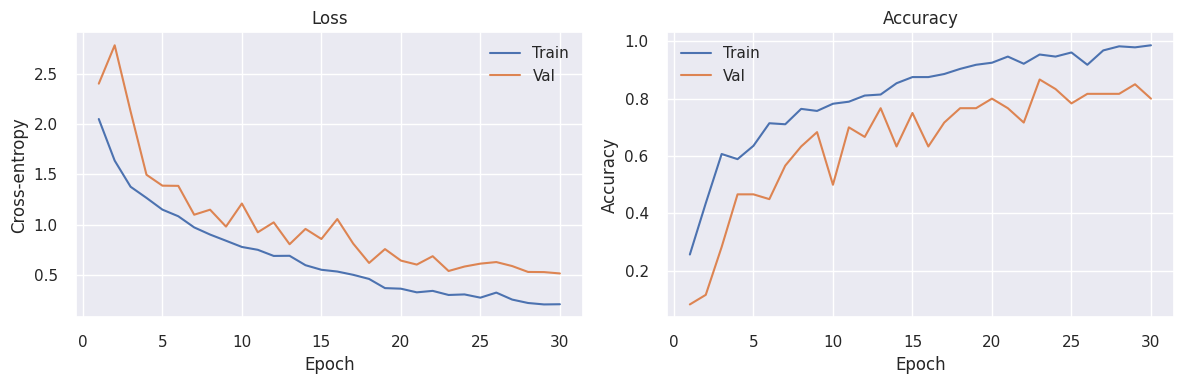

In [20]:
def plot_history(history: Dict[str, List[float]]):
    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_range, history["train_loss"], label="Train")
    axes[0].plot(epochs_range, history["val_loss"], label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-entropy")
    axes[0].legend()

    axes[1].plot(epochs_range, history["train_acc"], label="Train")
    axes[1].plot(epochs_range, history["val_acc"], label="Val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_history(history)


In [21]:
def collect_predictions(model: nn.Module, loader: DataLoader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    filenames, categories = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating", leave=False):
            inputs = batch["input"].to(device)
            labels = batch["label"].to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())
            filenames.extend(batch["filename"])
            categories.extend(batch["category"])

    return np.array(y_true), np.array(y_pred), np.array(y_prob), filenames, categories


y_true, y_pred, y_prob, test_files, test_categories = collect_predictions(model, test_loader)

test_acc = (y_true == y_pred).mean()
print(f"Test accuracy: {test_acc:.3f}")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=SELECTED_CLASSES,
        digits=4,
    )
)


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

Test accuracy: 0.621
              precision    recall  f1-score   support

  helicopter     0.7692    1.0000    0.8696        10
    chainsaw     0.7143    0.6667    0.6897        15
       siren     0.7500    0.6000    0.6667        10
    car_horn     0.0000    0.0000    0.0000         0
      engine     0.0000    0.0000    0.0000         5
       train     0.4545    0.5000    0.4762        10
church_bells     0.7273    0.8000    0.7619        10
    airplane     0.3333    0.2857    0.3077         7
   fireworks     0.5000    0.6000    0.5455        10
    hand_saw     1.0000    0.7000    0.8235        10

    accuracy                         0.6207        87
   macro avg     0.5249    0.5152    0.5141        87
weighted avg     0.6329    0.6207    0.6199        87



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


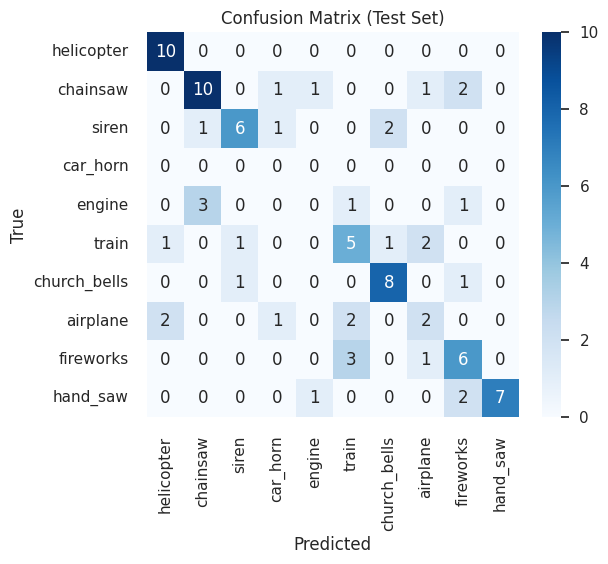

In [22]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=SELECTED_CLASSES, yticklabels=SELECTED_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()


File: fireworks/fireworks_Sound_Effects_Of_Fireworks___10_MINUTES___High_Quality_Audio_6.wav
True label: fireworks
Predicted: fireworks (88.59%)


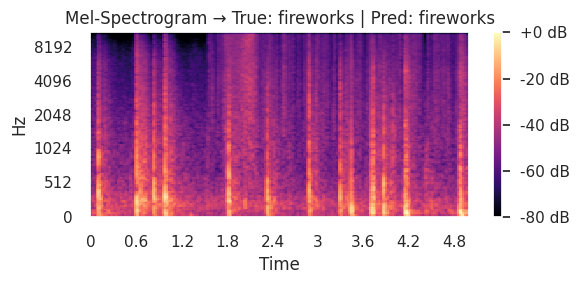

,class,probability
8,fireworks,0.885933
5,train,0.105261
1,chainsaw,0.003586
9,hand_saw,0.002397
3,car_horn,0.000753
4,engine,0.000598
7,airplane,0.000546
6,church_bells,0.000511
0,helicopter,0.000294
2,siren,0.000122


------------------------------------------------------------
File: helicopter/Helicopter Sound Effect.wav
True label: helicopter
Predicted: helicopter (33.72%)


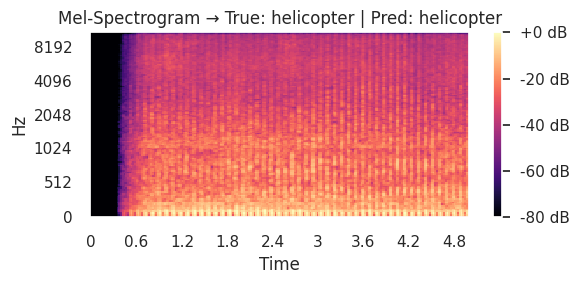

,class,probability
0,helicopter,0.337165
4,engine,0.282086
1,chainsaw,0.127933
3,car_horn,0.088814
5,train,0.085335
7,airplane,0.053490
8,fireworks,0.017373
2,siren,0.003704
9,hand_saw,0.002744
6,church_bells,0.001355


------------------------------------------------------------
File: siren/Siren 2.wav
True label: siren
Predicted: chainsaw (54.53%)


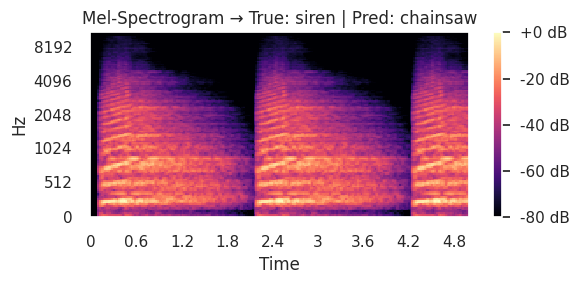

,class,probability
1,chainsaw,0.545317
6,church_bells,0.133392
7,airplane,0.113552
3,car_horn,0.100078
8,fireworks,0.045709
2,siren,0.016576
5,train,0.016172
0,helicopter,0.012121
9,hand_saw,0.011496
4,engine,0.005586


------------------------------------------------------------


In [23]:
def predict_clip(model: nn.Module, file_path: Path) -> Tuple[str, float, np.ndarray]:
    signal, _ = librosa.load(file_path, sr=SAMPLE_RATE)
    signal = pad_or_trim(signal)
    mel = waveform_to_mel(signal)
    mel = normalize_mel(mel)
    tensor = torch.tensor(mel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_idx = probs.argmax()
    return idx_to_class[pred_idx], probs[pred_idx], probs


def show_sample_predictions(num_samples: int = 4):
    samples = test_df.sample(num_samples, random_state=RANDOM_SEED)
    for _, row in samples.iterrows():
        file_path = TEST_AUDIO_ROOT / row["filename"]
        pred_label, pred_conf, probs = predict_clip(model, file_path)
        true_label = row["category"]

        print(f"File: {row['filename']}")
        print(f"True label: {true_label}")
        print(f"Predicted: {pred_label} ({pred_conf:.2%})")

        plt.figure(figsize=(6, 3))
        mel = waveform_to_mel(pad_or_trim(librosa.load(file_path, sr=SAMPLE_RATE)[0]))
        librosa.display.specshow(mel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel")
        plt.title(f"Mel-Spectrogram → True: {true_label} | Pred: {pred_label}")
        plt.colorbar(format="%+2.0f dB")
        plt.tight_layout()
        plt.show()

        prob_df = pd.DataFrame({"class": SELECTED_CLASSES, "probability": probs})
        prob_df = prob_df.sort_values("probability", ascending=False)
        display(prob_df)
        print("-" * 60)


show_sample_predictions(num_samples=3)
